**PROJECT:Dynamic Sensor-Based Fault Detection & Drift Monitoring System**
   **PHASE 1:Problem Framing, Data Ingestion & Stream Simulation
      #Section 1: Local Environment Setup & Data Extraction
      Objective: Programmatically extract the downloaded academic dataset from the local environment download path and verify its structure inside             our working repository directory.

      Data Source: UCI Machine Learning Repository (AI4I 2020 Predictive Maintenance Dataset)
      Target Output: Extraction of `ai4i2020.csv` into the current working directory.

In [82]:
import os
import zipfile
#Defining Path
download_path = r"C:\Users\samma\Downloads\ai4i+2020+predictive+maintenance+dataset.zip"
current_project_dir = os.getcwd()
# Extracting the zip archive
if os.path.exists(download_path):
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall(current_project_dir)
    print(f"Success! File extracted to: {current_project_dir}")
    print("Files in directory:", [f for f in os.listdir() if f.endswith('.csv')])
else:
    print(f" Error: Could not find the zip file at {download_path}")
    print("Please double check if the file extension is '.zip'.")

Success! File extracted to: C:\Sensor_Data
Files in directory: ['ai4i2020.csv', 'historical_baseline.csv', 'streaming_pool.csv']


Importing Necessary Libraries

In [83]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

 Reading Data From CSV File And Splitting It Into Two Separate Files

In [84]:
sensorData=pd.read_csv("ai4i2020.csv" , index_col='UDI')
pivot_index = 5000   #Splitting Index
historical_df = sensorData.iloc[:pivot_index]   #Saving the first half in a new dataframe
streaming_pool_df = sensorData.iloc[pivot_index:]  #Saving the other half into another new dataframe
historical_df.to_csv("historical_baseline.csv", index=False)  #Converting dataframe into a csv file
streaming_pool_df.to_csv("streaming_pool.csv", index=False)  #Converting dataframe into a csv file

**Exploratory Data Anaalysis**

In [85]:
sensorData.shape
sensorData.sample(10)
sensorData.describe()
sensorData.duplicated().sum()
sensorData.corr(numeric_only=True)
sensorData.info()
print(historical_df['Type'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  str    
 1   Type                     10000 non-null  str    
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
 8   TWF                      10000 non-null  int64  
 9   HDF                      10000 non-null  int64  
 10  PWF                      10000 non-null  int64  
 11  OSF                      10000 non-null  int64  
 12  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 1.1 MB
<ArrowStringArray>
['M', 'L', 'H']

In [86]:
#Univariate Analysis

#Categorical Data
print(historical_df['TWF'].value_counts())
print(historical_df['HDF'].value_counts())
print(historical_df['PWF'].value_counts())
print(historical_df['OSF'].value_counts())
print(historical_df['RNF'].value_counts())
print(historical_df['Machine failure'].value_counts()) 

#Numerical Data
# 1. Boxplots
#sns.boxplot(data=historical_df, x='Air temperature [K]')
#sns.boxplot(data=historical_df, x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='Torque [Nm]')
#sns.boxplot(data=historical_df, x='Tool wear [min]')
# 2. KDE Distribution Plots
#sns.displot(data=historical_df, x='Air temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Process temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Torque [Nm]', kind='kde')
#sns.displot(data=historical_df, x='Tool wear [min]', kind='kde')
#sns.displot(data=historical_df, x='Rotational speed [rpm]', kind='kde')

TWF
0    4979
1      21
Name: count, dtype: int64
HDF
0    4885
1     115
Name: count, dtype: int64
PWF
0    4942
1      58
Name: count, dtype: int64
OSF
0    4949
1      51
Name: count, dtype: int64
RNF
0    4992
1       8
Name: count, dtype: int64
Machine failure
0    4765
1     235
Name: count, dtype: int64


In [87]:
#Bivariate Analysis

#Scatter Plots
#sns.scatterplot(data=historical_df, x='Air temperature [K]', y='Process temperature [K]')
#sns.scatterplot(data=historical_df, x='Rotational speed [rpm]', y='Torque [Nm]')
#Bar Plots
#sns.barplot(data=historical_df, x='Type', y='Torque [Nm]')
#sns.barplot(data=historical_df, x='Type', y='Rotational speed [rpm]')
#sns.barplot(data=historical_df, x='Type', y='Tool wear [min]')
#Box Plots
#sns.boxplot(data=historical_df[historical_df['TWF'] == 1],x='Tool wear [min]')
#sns.boxplot(data=historical_df, x='TWF', y='Tool wear [min]')
#sns.boxplot(data=historical_df[historical_df['PWF'] == 1],x='Torque [Nm]') 
#sns.boxplot(data=historical_df, x='PWF', y='Torque [Nm]')
#sns.boxplot(data=historical_df[historical_df['HDF'] == 1],x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='HDF', y='Process temperature [K]')
#Crosstabs
#type_vs_twf = pd.crosstab(historical_df['Type'], historical_df['TWF'],normalize='index') *100
#print(type_vs_twf)
#type_vs_twf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_osf = pd.crosstab(historical_df['Type'], historical_df['OSF'],normalize='index') *100
#print(type_vs_osf)
#type_vs_osf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_hdf = pd.crosstab(historical_df['Type'], historical_df['HDF'],normalize='index') *100
#print(type_vs_hdf)
#type_vs_hdf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_pwf = pd.crosstab(historical_df['Type'], historical_df['PWF'],normalize='index') *100
#print(type_vs_pwf)
#type_vs_pwf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_rnf =historical_df.groupby('Type')['RNF'].mean()*100  #this and above are both same commands just the difference is that above shows all three types and working and failure for each type but this shows three type and only failure for each type as when mean is used mean of 0,1 is 1. 
#print(type_vs_rnf)
#type_vs_rnf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])

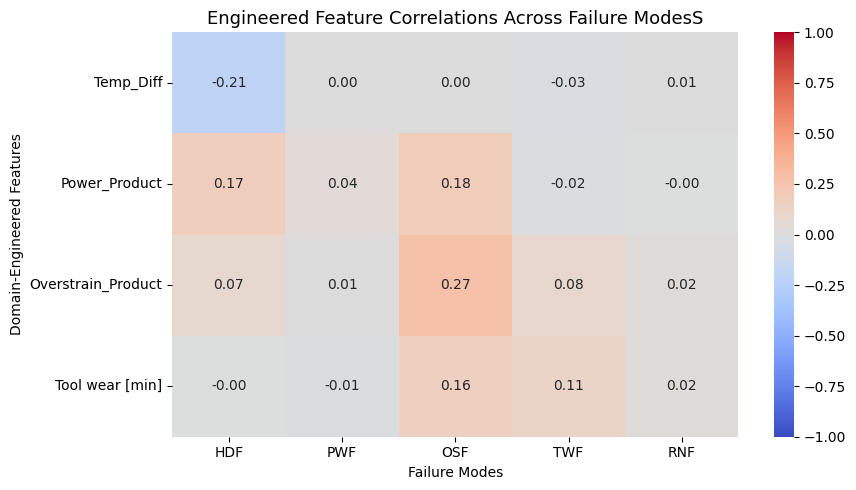

In [88]:
#Multivariate Analysis

#heatmap
#1
#plt.figure(figsize=(10, 8))
#numeric_df = historical_df.select_dtypes(include=['number'])  #Isolating the numerical column
#correlation_matrix = numeric_df.corr(method='pearson')   #Computing correlation 
#sns.heatmap(data=correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',vmin=-1, vmax=1)
#plt.title("Pearson Correlation Matrix (Checking for Multicollinearity)", fontsize=14)
#2
#sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
#failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
#cross_corr = historical_df[sensor_cols + failure_cols].corr().loc[sensor_cols, failure_cols]
#plt.figure(figsize=(8, 5))
#sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#plt.title("Sensor Correlations Across All Distinct Failure Modes")
#plt.show()
historical_df['Temp_Diff'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']
engineered_cols = ['Temp_Diff', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()
#pairplots
#a
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='TWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Tool Wear Failures (TWF)", y=1.02, fontsize=14)
#plt.show()
#b
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'PWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='PWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Power Wear Failures (PWF)", y=1.02, fontsize=14)
#plt.show()
#c
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'OSF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='OSF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Over Strain Failures (OSF)", y=1.02, fontsize=14)
#plt.show()
#3 Variable scatter plot
#plt.figure(figsize=(9, 6))
#sns.scatterplot(data=historical_df,x='Air temperature [K]',y='Process temperature [K]',hue='HDF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
#plt.title("Operational Overload Boundaries: Air Temperature vs. Process Temperature", fontsize=13)
#plt.xlabel("Air Temperature [K]")
#plt.ylabel("Process Temperature [K]")
#plt.grid(True, linestyle='--', alpha=0.5)
#plt.show()


**Feature Engineering**

In [89]:
#Feature Construction
historical_df['Temperature_Difference'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']

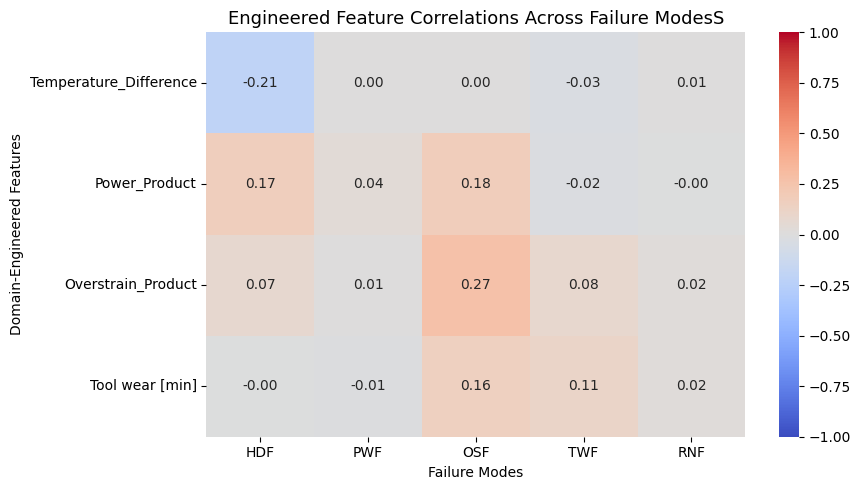

In [90]:
#Heatmap
engineered_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()

In [91]:
import joblib
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

# 1. Import Custom Transformers from Helper Module
from custom_transformers import IQROutlierClipper, MaintenanceFeatureEngineer

set_config(transform_output="pandas")

# 2. Train-Test Split
X = historical_df.drop(columns=['Machine failure', 'Product ID', 'UDI'], errors='ignore')
Y = historical_df['Machine failure']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=0
)

# 3. Raw Feature Definitions
raw_numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
raw_ordinal_cols = ['Type']

# 4. Standalone Raw Preprocessor
raw_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), raw_numeric_cols),
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(categories=[['L', 'M', 'H']], handle_unknown='use_encoded_value', unknown_value=-1))
        ]), raw_ordinal_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print("✅ Shell 1 Base components defined successfully.")

✅ Shell 1 Base components defined successfully.


In [92]:
%%writefile custom_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class MaintenanceFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        X = X.copy()
        
        # 1. Temperature Ratio
        if 'Process temperature [K]' in X.columns and 'Air temperature [K]' in X.columns:
            X['Temp_Ratio'] = X['Process temperature [K]'] / (X['Air temperature [K]'] + 1e-6)
        else:
            X['Temp_Ratio'] = 0.0

        # 2. Power Proxy & Strain Ratio
        if 'Rotational speed [rpm]' in X.columns and 'Torque [Nm]' in X.columns:
            X['Power_Proxy'] = X['Torque [Nm]'] * X['Rotational speed [rpm]']
            X['Strain_Ratio'] = X['Torque [Nm]'] / (X['Rotational speed [rpm]'] + 1e-6)
        else:
            X['Power_Proxy'] = 0.0
            X['Strain_Ratio'] = 0.0

        # 3. Power to Wear Ratio
        if 'Power_Proxy' in X.columns and 'Tool wear [min]' in X.columns:
            X['Power_To_Wear_Ratio'] = X['Power_Proxy'] / (X['Tool wear [min]'] + 1e-6)
        else:
            X['Power_To_Wear_Ratio'] = 0.0

        # 4. Thermal-Wear Interaction
        if 'Temp_Ratio' in X.columns and 'Tool wear [min]' in X.columns:
            X['Thermal_Wear_Interaction'] = X['Temp_Ratio'] * X['Tool wear [min]']
        else:
            X['Thermal_Wear_Interaction'] = 0.0

        return X

class IQROutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            for col in X.select_dtypes(include=[np.number]).columns:
                q25 = X[col].quantile(0.25)
                q75 = X[col].quantile(0.75)
                iqr = q75 - q25
                self.lower_bounds_[col] = q25 - (self.factor * iqr)
                self.upper_bounds_[col] = q75 + (self.factor * iqr)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            return X
        X = X.copy()
        for col, lower in self.lower_bounds_.items():
            if col in X.columns:
                upper = self.upper_bounds_[col]
                X[col] = np.clip(X[col], lower, upper)
        return X

Overwriting custom_transformers.py


Model Training And Prediction 

In [93]:
import joblib
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline

from custom_transformers import MaintenanceFeatureEngineer

# ==============================================================================
# MODEL 1: Standalone Logistic Regression (Benchmarking)
# ==============================================================================
logistic_pipeline = Pipeline([
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('preprocessor', raw_preprocessor),
    ('classifier', LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42))
])

logistic_pipeline.fit(x_train, y_train)
logistic_preds = logistic_pipeline.predict(x_test)

print("=" * 60)
print("BENCHMARK 1: Logistic Regression")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, logistic_preds):.4f}\n")
print(classification_report(y_test, logistic_preds, zero_division=0))

# ==============================================================================
# MODEL 2: Standalone Random Forest (Benchmarking)
# ==============================================================================
rf_pipeline = Pipeline([
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('preprocessor', raw_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_pipeline.fit(x_train, y_train)
rf_preds = rf_pipeline.predict(x_test)

print("\n" + "=" * 60)
print("BENCHMARK 2: Random Forest")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print(classification_report(y_test, rf_preds, zero_division=0))

# ==============================================================================
# FINAL PRODUCTION PIPELINE: Soft Voting Ensemble
# ==============================================================================

# 1. Define Sub-Models
hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced', max_iter=200, learning_rate=0.05, random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=150, class_weight='balanced', max_depth=12, random_state=42, n_jobs=-1
)
log_reg = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)

# 2. Wrap Estimator for Calibration
calibrated_log_reg = CalibratedClassifierCV(estimator=log_reg, method='sigmoid', cv=3)

# 3. Soft Voting Ensemble
ensemble_voting = VotingClassifier(
    estimators=[
        ('hgb', hgb_model),
        ('rf', rf_model),
        ('log_reg', calibrated_log_reg)
    ],
    voting='soft',
    weights=[1.5, 1.2, 1.0]
)

# 4. End-to-End Production Pipeline
final_production_pipeline = Pipeline([
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('preprocessor', raw_preprocessor),
    ('classifier', ensemble_voting)
])

# 5. Fit & Evaluate Production Pipeline
print("\n" + "=" * 60)
print("Fitting Production Ensemble Pipeline...")
final_production_pipeline.fit(x_train, y_train)

ensemble_probs = final_production_pipeline.predict_proba(x_test)[:, 1]
ensemble_preds = (ensemble_probs >= 0.50).astype(int)
baseline_f1 = f1_score(y_test, ensemble_preds, zero_division=0)

print("\n" + "=" * 60)
print("FINAL PRODUCTION MODEL: Calibrated Soft Voting Ensemble (@ 0.50)")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, ensemble_preds):.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, ensemble_preds, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_preds))

BENCHMARK 1: Logistic Regression
Accuracy: 0.8080

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1430
           1       0.17      0.81      0.28        70

    accuracy                           0.81      1500
   macro avg       0.58      0.81      0.59      1500
weighted avg       0.95      0.81      0.86      1500


BENCHMARK 2: Random Forest
Accuracy: 0.9747

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1430
           1       0.85      0.56      0.67        70

    accuracy                           0.97      1500
   macro avg       0.91      0.78      0.83      1500
weighted avg       0.97      0.97      0.97      1500


Fitting Production Ensemble Pipeline...

FINAL PRODUCTION MODEL: Calibrated Soft Voting Ensemble (@ 0.50)
Accuracy:          0.9747
Baseline F1-Score: 0.7121

Classification Report:
              precision    recall  f1-score   support

           

In [ ]:
%%writefile train_master.py
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. IMPORT CUSTOM TRANSFORMERS
from custom_transformers import IQROutlierClipper, MaintenanceFeatureEngineer

# Set up storage directory
os.makedirs('model_store', exist_ok=True)
MASTER_DATA_PATH = 'model_store/historical_master_data.csv'
PAYLOAD_PATH = 'model_store/production_v1.joblib'

# 2. Load and Store Master Baseline Data
historical_df = pd.read_csv('predictive_maintenance.csv') # adjust filename if needed
historical_df.to_csv(MASTER_DATA_PATH, index=False)

# 3. Train-Test Split
X = historical_df.drop(columns=['Machine failure', 'Product ID'], errors='ignore')
Y = historical_df['Machine failure']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=42
)

# 4. Column Groups
ordinal_cols = ['Type']
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temperature_Difference',
    'Power_Product',
    'Overstrain_Product'
]

# 5. Preprocessor Setup
numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('outlier_clipper', IQROutlierClipper(factor=1.5)),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['L', 'M', 'H']], handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('ord', ordinal_pipeline, ordinal_cols)
    ],
    remainder='drop'
)

# 6. Champion Model Pipeline (HistGradientBoosting)
hgb_pipeline = Pipeline([
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        max_iter=200,
        learning_rate=0.05,
        random_state=42
    ))
])

hgb_pipeline.fit(x_train, y_train)

# 7. Evaluate Baseline Metrics
OPTIMAL_THRESHOLD = 0.8900
test_probs = hgb_pipeline.predict_proba(x_test)[:, 1]
test_preds = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

baseline_f1 = f1_score(y_test, test_preds, zero_division=0)
baseline_precision = precision_score(y_test, test_preds, zero_division=0)
baseline_recall = recall_score(y_test, test_preds, zero_division=0)
baseline_acc = accuracy_score(y_test, test_preds)

print("=" * 60)
print("BASE PLAN EXPORT SUMMARY")
print("=" * 60)
print(f"Accuracy:  {baseline_acc:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")

# 8. Export Unified Payload
payload = {
    'pipeline': hgb_pipeline,
    'optimal_threshold': OPTIMAL_THRESHOLD,
    'baseline_metrics': {
        'f1': baseline_f1,
        'precision': baseline_precision,
        'recall': baseline_recall,
        'accuracy': baseline_acc
    },
    'feature_names': numeric_cols + ordinal_cols
}

joblib.dump(payload, PAYLOAD_PATH)
print(f"\nSaved initial master pipeline payload to '{PAYLOAD_PATH}'.")
print(f"Saved initial master CSV dataset to '{MASTER_DATA_PATH}'.")

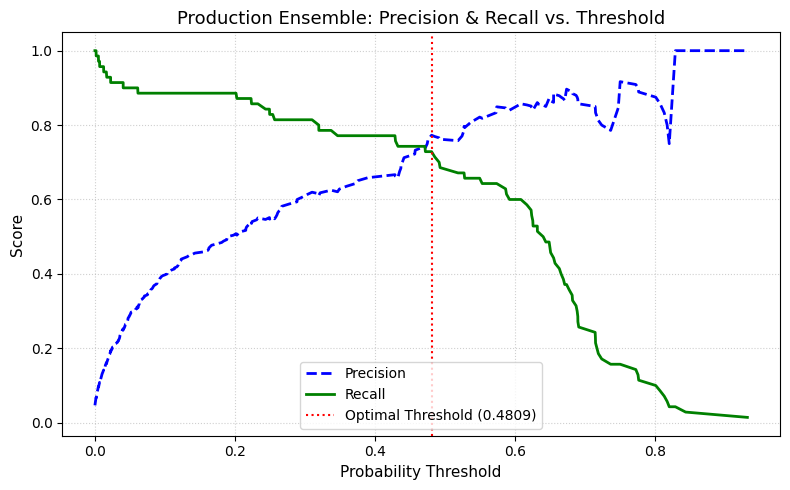


--- Champion Model: Production Ensemble (Tuned Threshold = 0.4809) ---
Default F1-Score (@ 0.50): 0.7121
Tuned F1-Score (@ 0.4809): 0.7500

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1430
           1       0.77      0.73      0.75        70

    accuracy                           0.98      1500
   macro avg       0.88      0.86      0.87      1500
weighted avg       0.98      0.98      0.98      1500

Confusion Matrix:
[[1415   15]
 [  19   51]]


In [94]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve

# Calculate probabilities using the fitted final production ensemble
ensemble_probs = final_production_pipeline.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, ensemble_probs)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else float(thresholds[-1])

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.axvline(x=best_threshold, color='r', linestyle=':', label=f'Optimal Threshold ({best_threshold:.4f})')

plt.xlabel('Probability Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Production Ensemble: Precision & Recall vs. Threshold', fontsize=13)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

tuned_ensemble_preds = (ensemble_probs >= best_threshold).astype(int)

print(f"\n--- Champion Model: Production Ensemble (Tuned Threshold = {best_threshold:.4f}) ---")
print(f"Default F1-Score (@ 0.50): {baseline_f1:.4f}")
print(f"Tuned F1-Score (@ {best_threshold:.4f}): {f1_scores[best_idx]:.4f}\n")
print(classification_report(y_test, tuned_ensemble_preds, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_ensemble_preds))

Deployment

In [95]:
import joblib

model_payload = {
    'pipeline': final_production_pipeline,
    'default_threshold': float(best_threshold),
    'baseline_f1': float(f1_scores[best_idx]),
    'required_cols': [
        'Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type'
    ]
}

joblib.dump(model_payload, 'predictive_maintenance_pipeline.joblib')
print(f"✅ Production payload successfully exported to 'predictive_maintenance_pipeline.joblib' (Optimal Threshold: {best_threshold:.4f}, Baseline F1: {f1_scores[best_idx]:.4f})")

✅ Production payload successfully exported to 'predictive_maintenance_pipeline.joblib' (Optimal Threshold: 0.4809, Baseline F1: 0.7500)


In [96]:
%%writefile app.py
import os
import json
import joblib
import datetime
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# Import Tier 2 online retraining function from your retrain_module.py
from retrain_module import execute_tier2_retrain

# --- PATH CONFIGURATION ---
PAYLOAD_PATH = 'model_store/production_v1.joblib'
MASTER_DATA_PATH = 'model_store/historical_master_data.csv'
AUDIT_LOG_PATH = 'model_store/audit_log.json'

st.set_page_config(page_title="Sensor Failure MLOps Dashboard", layout="wide")

# --- HELPER FUNCTIONS FOR AUDIT LOGGING ---
def load_audit_logs():
    if os.path.exists(AUDIT_LOG_PATH):
        with open(AUDIT_LOG_PATH, 'r') as f:
            return json.load(f)
    return []

def log_audit_event(event_type, details):
    logs = load_audit_logs()
    event = {
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "event_type": event_type,
        "details": details
    }
    logs.append(event)
    with open(AUDIT_LOG_PATH, 'w') as f:
        json.dump(logs, f, indent=4)

# --- LOAD MASTER ARTIFACTS ---
@st.cache_resource
def load_artifacts():
    if not os.path.exists(PAYLOAD_PATH) or not os.path.exists(MASTER_DATA_PATH):
        st.error("Model artifacts missing! Please run 'python train_master.py' first.")
        st.stop()
    payload = joblib.load(PAYLOAD_PATH)
    master_df = pd.read_csv(MASTER_DATA_PATH)
    return payload, master_df

payload, master_df = load_artifacts()
pipeline = payload['pipeline']
base_metrics = payload['baseline_metrics']
default_threshold = payload['optimal_threshold']

# --- SIDEBAR: PRECISION-RECALL EXPLORER ---
st.sidebar.title("⚙️ MLOps Controls & Tuning")

st.sidebar.subheader("Precision-Recall Threshold Explorer")

# Generate PR Curve Data from Master Training Split
X_master = master_df.drop(columns=['Machine failure', 'Product ID'], errors='ignore')
y_master = master_df['Machine failure']
probs_master = pipeline.predict_proba(X_master)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_master, probs_master)

# Plot interactive PR Curve in Sidebar
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recalls, y=precisions, mode='lines', name='PR Curve', line=dict(color='firebrick', width=2)))
fig_pr.update_layout(
    title="Master Precision-Recall Curve",
    xaxis_title="Recall",
    yaxis_title="Precision",
    height=250,
    margin=dict(l=10, r=10, t=30, b=10)
)
st.sidebar.plotly_chart(fig_pr, use_container_width=True)

# Decision Threshold Slider with Tier 1 Logging
active_threshold = st.sidebar.slider(
    "Active Decision Threshold",
    min_value=0.10,
    max_value=0.95,
    value=float(default_threshold),
    step=0.01
)

if active_threshold != default_threshold:
    if st.sidebar.button("Log Tier 1 Threshold Adjustment"):
        log_audit_event("Tier 1 Calibration", f"Decision threshold manual override from {default_threshold:.4f} to {active_threshold:.4f}")
        st.sidebar.success("Logged Tier 1 threshold update to audit trail!")

# Calculate trade-offs dynamically based on slider
slider_preds = (probs_master >= active_threshold).astype(int)
st.sidebar.markdown(f"**Recall:** `{recall_score(y_master, slider_preds):.4f}` | **Precision:** `{precision_score(y_master, slider_preds):.4f}`")

# --- MAIN DASHBOARD INTERFACE ---
st.title("🛡️ Predictive Maintenance Monitoring & Drift Dashboard")

tab1, tab2, tab3 = st.tabs(["🚀 Inference & Batch Analysis", "📊 Data & Feature Drift Explorer", "📜 Retraining Logs & Audit Trail"])

# --- TAB 1: INFERENCE & BATCH ANALYSIS ---
with tab1:
    st.header("Batch Inference Upload")
    uploaded_file = st.file_uploader("Upload Sensor CSV Batch Data", type=["csv"], key="batch_uploader")

    if uploaded_file is not None:
        batch_df = pd.read_csv(uploaded_file)
        st.write("### Incoming Batch Preview", batch_df.head(3))

        # Run Predictions
        batch_probs = pipeline.predict_proba(batch_df)[:, 1]
        batch_preds = (batch_probs >= active_threshold).astype(int)
        
        batch_df['Failure_Probability'] = batch_probs
        batch_df['Predicted_Failure'] = batch_preds

        col1, col2, col3 = st.columns(3)
        col1.metric("Total Batch Records", len(batch_df))
        col2.metric("Predicted Failures", int(batch_preds.sum()))
        col3.metric("Failure Rate", f"{(batch_preds.sum()/len(batch_df))*100:.2f}%")

        st.dataframe(batch_df[['UDI', 'Type', 'Failure_Probability', 'Predicted_Failure']].head(10))

        # Tier 2 Retrain Action Button
        st.divider()
        st.subheader("Tier 2 Emergency Retraining Trigger")
        if 'Machine failure' in batch_df.columns:
            if st.button("Trigger Tier 2 Online Retraining"):
                with st.spinner("Appending deduplicated data and retraining pipeline..."):
                    metrics = execute_tier2_retrain(batch_df)
                    log_audit_event("Tier 2 Online Retrain", f"Retrained model with {metrics['new_records_added']} new records. New baseline F1: {metrics['updated_f1']:.4f}")
                    st.success(f"Successfully retrained! Added {metrics['new_records_added']} unique records.")
                    st.cache_resource.clear()
        else:
            st.warning("Tier 2 Retraining requires ground-truth target labels ('Machine failure') in the CSV.")

# --- TAB 2: DATA & FEATURE DRIFT EXPLORER ---
with tab2:
    st.header("Feature Distribution & Data Drift Analysis")
    st.markdown("Compare distribution shifts between original master baseline data and incoming batch features.")

    if 'batch_df' in locals() and uploaded_file is not None:
        numeric_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
        selected_feature = st.selectbox("Select Feature to Analyze Drift", numeric_features)

        fig_drift = go.Figure()
        
        # Add Historical Baseline Distribution
        fig_drift.add_trace(go.Histogram(
            x=master_df[selected_feature],
            name='Historical Master Data',
            opacity=0.6,
            marker_color='royalblue',
            histnorm='probability density'
        ))

        # Add Incoming Batch Distribution
        fig_drift.add_trace(go.Histogram(
            x=batch_df[selected_feature],
            name='Incoming Batch Data',
            opacity=0.6,
            marker_color='orange',
            histnorm='probability density'
        ))

        fig_drift.update_layout(
            barmode='overlay',
            title=f"Overlay Distribution Comparison: {selected_feature}",
            xaxis_title=selected_feature,
            yaxis_title="Probability Density",
            height=450
        )
        
        st.plotly_chart(fig_drift, use_container_width=True)

        # Summary Metrics Comparison
        col_hist, col_batch = st.columns(2)
        with col_hist:
            st.markdown(f"**Historical Mean ({selected_feature}):** `{master_df[selected_feature].mean():.2f}`")
            st.markdown(f"**Historical Std:** `{master_df[selected_feature].std():.2f}`")
        with col_batch:
            st.markdown(f"**Batch Mean ({selected_feature}):** `{batch_df[selected_feature].mean():.2f}`")
            st.markdown(f"**Batch Std:** `{batch_df[selected_feature].std():.2f}`")
    else:
        st.info("Upload a batch CSV file in the 'Inference & Batch Analysis' tab to visualize data drift overlay charts.")

# --- TAB 3: RETRAINING LOGS & AUDIT TRAIL ---
with tab3:
    st.header("Retraining Audit Logs & Model History")
    st.markdown("Historic log of Tier 1 threshold adjustments and Tier 2 online retraining triggers.")

    logs = load_audit_logs()
    if logs:
        log_df = pd.DataFrame(logs)
        st.dataframe(log_df.sort_values(by="timestamp", ascending=False), use_container_width=True)

        if st.button("Clear Audit Log"):
            if os.path.exists(AUDIT_LOG_PATH):
                os.remove(AUDIT_LOG_PATH)
                st.experimental_rerun()
    else:
        st.info("No audit events logged yet. Adjust thresholds in the sidebar or trigger Tier 2 retraining to create log entries.")

Overwriting app.py


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
plotly

In [ ]:
%%writefile retrain_module.py
import os
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

MASTER_DATA_PATH = 'model_store/historical_master_data.csv'
PAYLOAD_PATH = 'model_store/production_v1.joblib'

def execute_tier2_retrain(new_batch_df):
    """
    Appends new batch data to master historical CSV without duplicates,
    retrains the production pipeline, evaluates performance, and updates production_v1.joblib.
    """
    if not os.path.exists(MASTER_DATA_PATH) or not os.path.exists(PAYLOAD_PATH):
        raise FileNotFoundError("Master storage files missing. Run initial setup script first.")

    # 1. Load Master Dataset and Existing Payload
    master_df = pd.read_csv(MASTER_DATA_PATH)
    payload = joblib.load(PAYLOAD_PATH)
    pipeline = payload['pipeline']
    active_threshold = payload['optimal_threshold']

    # 2. Append & Deduplicate by UDI
    combined_df = pd.concat([master_df, new_batch_df], ignore_index=True)
    if 'UDI' in combined_df.columns:
        combined_df.drop_duplicates(subset=['UDI'], keep='last', inplace=True)
    else:
        combined_df.drop_duplicates(inplace=True)

    # Save expanded historical data back to disk
    combined_df.to_csv(MASTER_DATA_PATH, index=False)

    # 3. Prepare Retraining Splits
    X_updated = combined_df.drop(columns=['Machine failure', 'Product ID'], errors='ignore')
    Y_updated = combined_df['Machine failure']

    X_train, X_test, y_train, y_test = train_test_split(
        X_updated, Y_updated, test_size=0.3, stratify=Y_updated, random_state=42
    )

    # 4. Retrain Complete Pipeline
    pipeline.fit(X_train, y_train)

    # 5. Evaluate Updated Baseline Metrics
    new_probs = pipeline.predict_proba(X_test)[:, 1]
    new_preds = (new_probs >= active_threshold).astype(int)

    updated_f1 = f1_score(y_test, new_preds, zero_division=0)
    updated_precision = precision_score(y_test, new_preds, zero_division=0)
    updated_recall = recall_score(y_test, new_preds, zero_division=0)
    updated_acc = accuracy_score(y_test, new_preds)

    # 6. Overwrite Payload Artifacts
    updated_payload = {
        'pipeline': pipeline,
        'optimal_threshold': active_threshold,
        'baseline_metrics': {
            'f1': updated_f1,
            'precision': updated_precision,
            'recall': updated_recall,
            'accuracy': updated_acc
        },
        'feature_names': payload['feature_names']
    }

    joblib.dump(updated_payload, PAYLOAD_PATH)

    return {
        'total_master_records': len(combined_df),
        'new_records_added': len(combined_df) - len(master_df),
        'updated_f1': updated_f1,
        'updated_precision': updated_precision,
        'updated_recall': updated_recall
    }

In [ ]:
import os
os.makedirs("tests", exist_ok=True)

In [ ]:
%%writefile tests/test_pipeline.py
import pytest
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, f1_score

from custom_transformers import MaintenanceFeatureEngineer, IQROutlierClipper


@pytest.fixture
def sample_raw_df():
    """Generates synthetic sensor data including missing values and outliers."""
    return pd.DataFrame({
        'UDI': [1, 2, 3, 4, 5],
        'Product ID': ['L47180', 'M14860', 'L47182', 'L47183', 'M14864'],
        'Type': ['L', 'M', 'L', 'L', 'M'],
        'Air temperature [K]': [298.1, np.nan, 298.3, 300.0, 297.5],
        'Process temperature [K]': [308.6, 308.7, 308.8, 310.0, 307.8],
        'Rotational speed [rpm]': [1500, 1400, 2800, 1550, 1450],
        'Torque [Nm]': [40.0, 42.0, 46.0, 38.0, 41.0],
        'Tool wear [min]': [0, 5, 12, 200, 250],
        'Machine failure': [0, 0, 1, 0, 1]
    })


def test_maintenance_feature_engineer(sample_raw_df):
    engineer = MaintenanceFeatureEngineer()
    transformed_df = engineer.transform(sample_raw_df)

    assert transformed_df['Air temperature [K]'].isna().sum() == 0

    expected_derived_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product']
    for col in expected_derived_cols:
        assert col in transformed_df.columns
        assert transformed_df[col].isna().sum() == 0

    expected_temp_diff = sample_raw_df['Process temperature [K]'] - transformed_df['Air temperature [K]']
    pd.testing.assert_series_equal(
        transformed_df['Temperature_Difference'], 
        expected_temp_diff, 
        check_names=False
    )


def test_iqr_outlier_clipper(sample_raw_df):
    clipper = IQROutlierClipper(factor=1.5)
    numeric_df = sample_raw_df[['Rotational speed [rpm]', 'Torque [Nm]']].fillna(1500)
    
    clipped_df = clipper.fit_transform(numeric_df)

    assert clipped_df.shape == numeric_df.shape
    assert clipped_df['Rotational speed [rpm]'].max() < 2800


def test_inference_output_shape(sample_raw_df):
    X_batch = sample_raw_df.drop(columns=['Machine failure', 'Product ID', 'UDI'])
    
    dummy_probs = np.array([0.1, 0.2, 0.85, 0.3, 0.9])
    threshold = 0.5
    predictions = (dummy_probs >= threshold).astype(int)

    assert len(predictions) == len(X_batch)
    assert set(predictions).issubset({0, 1})


def test_tier1_recalibration_logic():
    y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
    y_probs = np.array([0.1, 0.15, 0.2, 0.25, 0.45, 0.46, 0.47, 0.48, 0.8, 0.9])

    initial_preds = (y_probs >= 0.5).astype(int)
    initial_f1 = f1_score(y_true, initial_preds, zero_division=0)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    recalibrated_threshold = float(thresholds[best_idx])
    
    recalibrated_preds = (y_probs >= recalibrated_threshold).astype(int)
    recalibrated_f1 = f1_score(y_true, recalibrated_preds, zero_division=0)

    assert recalibrated_threshold < 0.5
    assert recalibrated_f1 > initial_f1

In [ ]:
import os
os.makedirs(".github/workflows", exist_ok=True)